# Load libraries


In [1]:
import numpy as np
import matplotlib.pyplot as PLT

from scipy.special import softmax,logsumexp

import os
import IPython

import tensorflow as tf
from tensorflow import keras

import keras.backend as K

from tensorflow.python.ops import array_ops, math_ops, state_ops

from tensorflow.keras.layers import Dense
from tensorflow.keras.models import Sequential


Duplicate key in file '/Users/nelsondiaz/.matplotlib/matplotlibrc', line 2 ('backend: GTK3Cairo')


# Download data

In [2]:

import ssl
ssl._create_default_https_context = ssl._create_unverified_context

from tensorflow.keras.datasets import mnist
from tensorflow.keras.datasets import cifar10

# Training / validation data + labels
if False:
   (x_train, y_train), (x_valid, y_valid) = mnist.load_data()
else:
   (x_train, y_train), (x_valid, y_valid) = cifar10.load_data()
    
print('Shape (training data):', x_train.shape, 'Labels:',y_train.shape)
print('Shape (valid/testing data):', x_valid.shape)


170500096/170498071 [==============================] - 10s 0us/step
Shape (training data): (50000, 32, 32, 3) Labels: (50000, 1)
Shape (valid/testing data): (10000, 32, 32, 3)


#### Visualization of a random element

Shape: (32, 32, 3) label: [3]


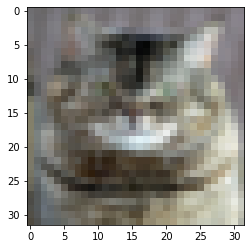

In [3]:
k = np.random.randint(0,x_train.shape[0])
    
PLT.imshow( x_train[k])
print('Shape:',x_train[k].shape, 'label:', y_train[k])


### Data pre-processing (normalization, etc.)

In [4]:
def stdPreproc(dIn,L=255.0, flagNorm=True, flagMean=True):

    dIn = dIn.astype("float")
    
    if flagNorm:
       dIn = dIn/L

    if flagMean:
       mean = np.mean(dIn, axis = 0)
       dIn -= mean
    
    return(dIn)

x_train = stdPreproc(x_train)
x_valid = stdPreproc(x_valid)

#### Data vectorization

In [5]:
trFlag = False

if trFlag:
   x_train = np.transpose( x_train.reshape(x_train.shape[0], int(x_train.size/x_train.shape[0]) ) )
   x_valid = np.transpose( x_valid.reshape(x_valid.shape[0], int(x_valid.size/x_valid.shape[0]) ) )
   # NOTE: in order to be consistant with lectures, then these matrices must be transpose
else:
   # TF does not use transpose
   x_train = x_train.reshape(x_train.shape[0], int(x_train.size/x_train.shape[0]) ) 
   x_valid = x_valid.reshape(x_valid.shape[0], int(x_valid.size/x_valid.shape[0]) ) 

print(x_train.shape)
print(x_valid.shape)


(50000, 3072)
(10000, 3072)


# TF based examples

In [6]:
print(y_train.shape)
print(y_valid.shape)

num_categories = 10

y_train = keras.utils.to_categorical(y_train, num_categories)
y_valid = keras.utils.to_categorical(y_valid, num_categories)

print(y_train.shape)
print(y_valid.shape)

History = {}

(50000, 1)
(10000, 1)
(50000, 10)
(10000, 10)


## TF built-in

In [7]:
K.clear_session()

model_tf = Sequential()

model_tf.add(Dense(units=512, activation='relu', input_shape=(3072,)))
model_tf.add(Dense(units = 10, activation='softmax'))

model_tf.summary()

model_tf.compile(loss='categorical_crossentropy', metrics=['accuracy'])
history_tf = model_tf.fit(
    x_train, y_train, epochs=10, verbose=1, validation_data=(x_valid, y_valid)
)

History['TF defualt'] = history_tf

 

Model: "sequential"
_________________________________________________________________
Layer (type)                 Output Shape              Param #   
dense (Dense)                (None, 512)               1573376   
_________________________________________________________________
dense_1 (Dense)              (None, 10)                5130      
Total params: 1,578,506
Trainable params: 1,578,506
Non-trainable params: 0
_________________________________________________________________
Epoch 1/10
1563/1563 [==============================] - 25s 16ms/step - loss: 1.7654 - accuracy: 0.4050 - val_loss: 1.6203 - val_accuracy: 0.4444
Epoch 2/10
1563/1563 [==============================] - 25s 16ms/step - loss: 1.4839 - accuracy: 0.4842 - val_loss: 1.5042 - val_accuracy: 0.4717
Epoch 3/10
1563/1563 [==============================] - 25s 16ms/step - loss: 1.3766 - accuracy: 0.5244 - val_loss: 1.5620 - val_accuracy: 0.4804
Epoch 4/10
1563/1563 [==============================] - 25s 16ms/step 

## TF adam

In [8]:
K.clear_session()


model_ad = Sequential()

model_ad.add(Dense(units=512, activation='relu', input_shape=(3072,)))
model_ad.add(Dense(units = 10, activation='softmax'))

model_ad.summary()

model_ad.compile(loss='categorical_crossentropy', metrics=['accuracy'], 
              optimizer=tf.keras.optimizers.Adam(learning_rate=0.001))
history_ad = model_ad.fit(
    x_train, y_train, epochs=10, verbose=1, validation_data=(x_valid, y_valid)
)

History['TF ADAM'] = history_ad


Model: "sequential"
_________________________________________________________________
Layer (type)                 Output Shape              Param #   
dense (Dense)                (None, 512)               1573376   
_________________________________________________________________
dense_1 (Dense)              (None, 10)                5130      
Total params: 1,578,506
Trainable params: 1,578,506
Non-trainable params: 0
_________________________________________________________________
Epoch 1/10
1563/1563 [==============================] - 12s 8ms/step - loss: 1.6998 - accuracy: 0.4196 - val_loss: 1.5361 - val_accuracy: 0.4576
Epoch 2/10
1563/1563 [==============================] - 13s 8ms/step - loss: 1.4633 - accuracy: 0.4919 - val_loss: 1.4772 - val_accuracy: 0.4842
Epoch 3/10
1563/1563 [==============================] - 13s 9ms/step - loss: 1.3760 - accuracy: 0.5210 - val_loss: 1.4831 - val_accuracy: 0.4890
Epoch 4/10
1563/1563 [==============================] - 13s 8ms/step - lo

## Plot summary

{'TF defualt': <tensorflow.python.keras.callbacks.History object at 0x7fc54bc9ee90>, 'TF ADAM': <tensorflow.python.keras.callbacks.History object at 0x7fc4a793cc90>}
dict_keys(['loss', 'accuracy', 'val_loss', 'val_accuracy'])


Text(0.5, 0, 'epoch')

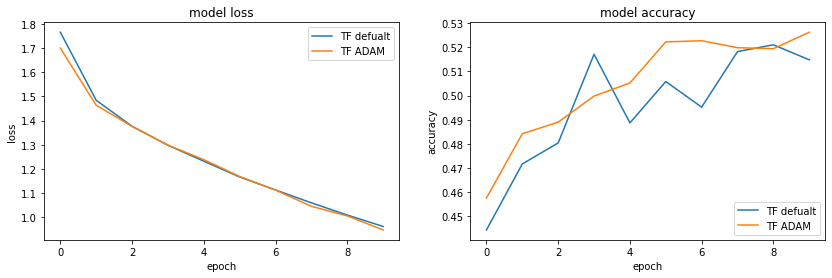

In [9]:
print(History)
print(History['TF defualt'].history.keys())

PLT.figure(figsize=(14, 4))

PLT.subplot(121)
# summarize history for loss

for k, keys in enumerate(History): 
    PLT.plot(History[keys].history['loss'],label=r'{0}'.format(keys))

PLT.legend(loc='upper right')    
PLT.title('model loss')
PLT.ylabel('loss')
PLT.xlabel('epoch')
    
PLT.subplot(122)
# summarize history for accuracy

for k, keys in enumerate(History): 
    PLT.plot(History[keys].history['val_accuracy'],label=r'{0}'.format(keys))

PLT.legend(loc='lower right')    
PLT.title('model accuracy')
PLT.ylabel('accuracy')
PLT.xlabel('epoch')


## Own solver

In [10]:
class HoSGD_sgd(keras.optimizers.Optimizer):
    def __init__(self, learning_rate=0.001, 
                 name="HoSGD_sgd", **kwargs):
        """Call super().__init__() """
        super().__init__(name, **kwargs)
        self._set_hyper("learning_rate", kwargs.get("lr", learning_rate)) # handle lr=learning_rate
        
    def _create_slots(self, var_list):
        """Slots.
        """
        
    @tf.function
    def _resource_apply_dense(self, grad, var):
        """Main routine
        """
        var_dtype = var.dtype.base_dtype

        pass
        
    def _resource_apply_sparse(self, grad, var):
        raise NotImplementedError

    def get_config(self):
        base_config = super().get_config()
        return {
            **base_config,
            "learning_rate": self._serialize_hyperparameter("learning_rate"),
        }
        


In [11]:
History_own = {}


In [12]:
K.clear_session()


model_own = Sequential()

model_own.add(Dense(units=512, activation='relu', input_shape=(3072,)))
model_own.add(Dense(units = 10, activation='softmax'))

model_own.summary()

model_own.compile(loss='categorical_crossentropy', metrics=['accuracy'], 
              optimizer=HoSGD_sgd(learning_rate=0.001))
history_own = model_own.fit(
    x_train, y_train, epochs=10, verbose=1, validation_data=(x_valid, y_valid)
)

History_own['HoSGD v1'] = history_own


Model: "sequential"
_________________________________________________________________
Layer (type)                 Output Shape              Param #   
dense (Dense)                (None, 512)               1573376   
_________________________________________________________________
dense_1 (Dense)              (None, 10)                5130      
Total params: 1,578,506
Trainable params: 1,578,506
Non-trainable params: 0
_________________________________________________________________
Epoch 1/10
1563/1563 [==============================] - 3s 2ms/step - loss: 2.3392 - accuracy: 0.1042 - val_loss: 2.3412 - val_accuracy: 0.1015
Epoch 2/10
1563/1563 [==============================] - 3s 2ms/step - loss: 2.3392 - accuracy: 0.1042 - val_loss: 2.3412 - val_accuracy: 0.1015
Epoch 3/10
1563/1563 [==============================] - 3s 2ms/step - loss: 2.3392 - accuracy: 0.1042 - val_loss: 2.3412 - val_accuracy: 0.1015
Epoch 4/10
1563/1563 [==============================] - 3s 2ms/step - loss: 

## Plot summary -- TF + own

Text(0.5, 0, 'epoch')

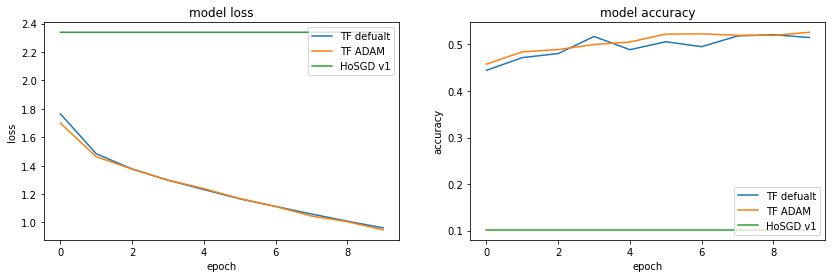

In [13]:

# summarize history for loss
PLT.figure(figsize=(14, 4))

PLT.subplot(121)
for k, keys in enumerate(History): 
    PLT.plot(History[keys].history['loss'],label=r'{0}'.format(keys))
for k, keys in enumerate(History_own): 
    PLT.plot(History_own[keys].history['loss'],label=r'{0}'.format(keys))

PLT.legend(loc='upper right')    
PLT.title('model loss')
PLT.ylabel('loss')
PLT.xlabel('epoch')

PLT.subplot(122)
for k, keys in enumerate(History): 
    PLT.plot(History[keys].history['val_accuracy'],label=r'{0}'.format(keys))
for k, keys in enumerate(History_own): 
    PLT.plot(History_own[keys].history['val_accuracy'],label=r'{0}'.format(keys))

PLT.legend(loc='lower right')    
PLT.title('model accuracy')
PLT.ylabel('accuracy')
PLT.xlabel('epoch')
